# pyvartools — examples tour

This notebook walks through the seven worked examples from the
[VARTOOLS examples site](https://hatpipe-doc.example/examples/).
Each section corresponds to one example page and contains the same
Python code shown there, plus the matplotlib plotting steps used to
produce the figures on the docs site.

## How to run

1. Install pyvartools — see `python/README.md` for setup. The notebook
   uses no features beyond the v1.6 release.
2. **Edit the next cell** and set `VARTOOLS_ROOT` to the absolute path
   of your vartools source root (the directory containing `EXAMPLES/`).
   The notebook will refuse to run any examples until that's done.
3. Run cells top to bottom.  Each example below the setup cell is
   independent — you can run any single section without running the
   others.

## What the docs site has that this notebook doesn't

The transit-search example on the docs site has two extra variants
("GPU transit search with CETRA" and "high-pass detrending + CETRA")
that depend on the optional [CETRA](https://github.com/leigh2/cetra)
package, which in turn requires a CUDA-capable GPU and the CUDA
toolkit. Those variants are intentionally omitted here — see the docs
page if you want to try them.


## Setup — set this before running anything else

Set `VARTOOLS_ROOT` below to the absolute path of your vartools source
root.  The cell will raise an error until you do, and the rest of the
notebook will fail because the relative `EXAMPLES/<n>` paths in each
example won't resolve.


In [1]:
# === Required: set this to your vartools source root. ===
# Example:
#   VARTOOLS_ROOT = "/home/yourname/vartools"
#   VARTOOLS_ROOT = "/Users/yourname/code/vartools"
#
# The directory must contain the `EXAMPLES/` subtree.
VARTOOLS_ROOT = "/home/jhartman/SVN/HATpipe/source/vartools/"

import os
if not VARTOOLS_ROOT:
    raise RuntimeError(
        "VARTOOLS_ROOT is not set.  Edit this cell, set it to the "
        "absolute path of your vartools source root (the directory "
        "containing EXAMPLES/), and re-run."
    )
if not os.path.isdir(os.path.join(VARTOOLS_ROOT, "EXAMPLES")):
    raise FileNotFoundError(
        f"VARTOOLS_ROOT={VARTOOLS_ROOT!r} has no EXAMPLES/ subdir.  "
        f"Point it at the vartools source root."
    )
os.chdir(VARTOOLS_ROOT)
print(f"Working directory set to {VARTOOLS_ROOT}")

Working directory set to /home/jhartman/SVN/HATpipe/source/vartools/


---

## Polynomial Detrending


# Polynomial detrending

Fit a quadratic polynomial in time to each light curve in a list and subtract
it, comparing the RMS before and after. A quadratic trend was injected into
`EXAMPLES/1`, so that LC shows the strongest improvement.

## Command line

```bash
./vartools -l EXAMPLES/lc_list \
    -rms \
    -expr listvar 'tzero=median(t)' \
    -linfit 'a*(t-tzero)*(t-tzero)+b*(t-tzero)+c' 'a,b,c' correctlc \
    -rms \
    -header
```

```text
#Name Mean_Mag_0 RMS_0 Expected_RMS_0 Npoints_0 Linfit_a_2 Linfit_erra_2 \
Linfit_b_2 Linfit_errb_2 Linfit_c_2 Linfit_errc_2 Mean_Mag_3 RMS_3 \
Expected_RMS_3 Npoints_3
EXAMPLES/1  10.24745   0.15944   0.00101  3122 0.00025540627746 1.956e-07 \
0.01438325055783 2.7252e-06 10.19165753386 2.0551e-05  -0.00017   0.00211 \
0.00101  3122
EXAMPLES/2  10.11802   0.03663   0.00102  3313 -5.0541833e-06 1.932e-07 \
0.000265335127 2.9164e-06 10.11151684161 1.9443e-05   0.00616   0.03657 \
0.00102  3313
...
```

## Python

In [2]:
import pyvartools as vt
from pyvartools import commands as cmd

lcs = [vt.LightCurve.from_file(f"EXAMPLES/{i}") for i in range(1, 11)]
batch = (vt.Pipeline()
        .rms()
        .expr("tzero=median(t)", vartype="listvar")
        .linfit(
            function="a*(t-tzero)*(t-tzero)+b*(t-tzero)+c",
            paramlist="a,b,c",
            correct_lc=True,
        )
        .rms()).run_batch(lcs)
print(batch.vars[["Name", "RMS_0", "Linfit_a_2", "Linfit_b_2",
                  "Linfit_c_2", "RMS_3"]])

  Name    RMS_0    Linfit_a_2  Linfit_b_2  Linfit_c_2    RMS_3
0    1  0.15944  2.554063e-04    0.014383   10.191658  0.00211
1    2  0.03663 -5.054183e-06    0.000265   10.111517  0.03657
2    3  0.00490 -1.270601e-07    0.000082   10.166625  0.00485
3    4  0.00209 -5.885294e-06    0.000087   10.351700  0.00205
4    5  0.00288 -3.693628e-06    0.000114   10.439339  0.00285
5    6  0.00209 -4.344227e-06    0.000071   10.527694  0.00206
6    7  0.00349 -6.353454e-07   -0.000006   10.569585  0.00348
7    8  0.00225  5.186242e-06   -0.000040   10.610926  0.00221
8    9  0.00187 -2.324837e-06    0.000050   10.731373  0.00186
9   10  0.00236 -4.817131e-06    0.000089   10.877842  0.00233


```text
  Name    RMS_0    Linfit_a_2  Linfit_b_2  Linfit_c_2    RMS_3
0    1  0.15944  2.554063e-04    0.014383   10.191658  0.00211
1    2  0.03663 -5.054183e-06    0.000265   10.111517  0.03657
2    3  0.00490 -1.270601e-07    0.000082   10.166625  0.00485
3    4  0.00209 -5.885294e-06    0.000087   10.351700  0.00205
4    5  0.00288 -3.693628e-06    0.000114   10.439339  0.00285
...
```

## Notes

The polynomial is written as a function of `(t - tzero)` rather than `t`
directly. For typical JDs near 2 453 000, evaluating `t*t` floats around
6e12 and differencing such values against each other loses precision;
`(t - tzero)*(t - tzero)` stays in a numerically well-behaved range. The
`listvar` form of `-expr` computes one `tzero` per light curve, used in the
subsequent `-linfit` on that LC.

`-linfit` is used here instead of the older `-decorr`, which accomplished the
same quadratic fit but with a rigid CLI syntax. `-linfit` accepts an arbitrary
analytic expression plus a comma-separated parameter list, and emits cleanly
named output columns (`Linfit_a_2`, `Linfit_b_2`, `Linfit_c_2`).

For `EXAMPLES/1` the RMS drops from 0.15944 mag to 0.00211 mag (a factor of
~75) — that LC had a quadratic injected into it. The other LCs in the list
were not modified, so their RMS barely changes.

---

## Period Finding


# Period finding

Run a Lomb-Scargle search on a light curve, then fit a single sinusoid at the
recovered period. `EXAMPLES/2` has a 1.2354-day, 0.05 mag sine injected into
it; the LS+harmonic fit should recover a peak-to-peak amplitude of ~0.1 mag.

## Command line

```bash
./vartools -i EXAMPLES/2 \
    -LS 1.0 2.0 0.01 1 0 \
    -harmonicfilter ls 0 0 1 EXAMPLES/OUTDIR1 \
    -oneline
```

```text
Name                                       = EXAMPLES/2
LS_Period_1_0                              =     1.23538924
Log10_LS_Prob_1_0                          = -4199.53506
LS_Periodogram_Value_1_0                   =    0.99711
LS_SNR_1_0                                 =   20.55841
HarmonicFilter_Mean_Mag_1                  =  10.12192
HarmonicFilter_Period_1_1                  =     1.23538924
HarmonicFilter_Per1_Fundamental_Sincoeff_1 =  -0.04836
HarmonicFilter_Per1_Fundamental_Coscoeff_1 =  -0.01286
HarmonicFilter_Per1_Amplitude_1            =   0.10009
```

## Python

In [3]:
import pyvartools as vt
from pyvartools import commands as cmd

lc = vt.LightCurve.from_file("EXAMPLES/2")

result = (vt.Pipeline()
        .LS(1.0, 2.0, 0.01, npeaks=1, save_periodogram=False)
        .harmonicfilter(period="ls", nharm=0, nsubharm=0)).run(lc)

print(result.vars)

Name                                                   2
LS_Period_1_0                                   1.235389
Log10_LS_Prob_1_0                            -4199.53506
LS_Periodogram_Value_1_0                         0.99711
LS_SNR_1_0                                      20.55841
HarmonicFilter_Mean_Mag_1                       10.12192
HarmonicFilter_Period_1_1                       1.235389
HarmonicFilter_Per1_Fundamental_Sincoeff_1      -0.04836
HarmonicFilter_Per1_Fundamental_Coscoeff_1      -0.01286
HarmonicFilter_Per1_Amplitude_1                  0.10009
dtype: object


```text
Name                                                   2
LS_Period_1_0                                   1.235389
Log10_LS_Prob_1_0                            -4199.53506
LS_Periodogram_Value_1_0                         0.99711
LS_SNR_1_0                                      20.55841
HarmonicFilter_Mean_Mag_1                       10.12192
HarmonicFilter_Period_1_1                       1.235389
HarmonicFilter_Per1_Fundamental_Sincoeff_1      -0.04836
HarmonicFilter_Per1_Fundamental_Coscoeff_1      -0.01286
HarmonicFilter_Per1_Amplitude_1                  0.10009
```

## Capture and plot the LS periodogram

Capture the full LS frequency-power spectrum for `EXAMPLES/2`, read it into
Python as a DataFrame, and plot power vs. period.

### Command line

```bash
./vartools -i EXAMPLES/2 \
    -LS 0.5 10.0 0.001 1 1 EXAMPLES/OUTDIR1 \
    -oneline
```

The `1 EXAMPLES/OUTDIR1` at the end of the `-LS` args enables periodogram
output and writes it to `EXAMPLES/OUTDIR1/2.ls`:

# Column 1 = Frequency in cycles per input light curve time unit.
# Column 2 = Unnormalized P(omega) (equation 5 of Zechmeister &
#            K\"urster 2009, A&A, 496, 577).
# Column 3 = Logarithm of the false alarm probability.
```text
0.10000931941552052 0.053061184352138094 -2148.7692206324959
0.10004060923970099 0.052928767751820608 -2147.0684086900499
0.10007189906388148 0.052797859472316708 -2145.3766960921931
...
```

### Python

`save_periodogram=True` captures the spectrum as a pandas DataFrame in
`result.files["LS_periodogram_0"]` (three columns: frequency, power, log₁₀
FAP). The example plots power against period with the LS peak marked.

          0         1            2
0  0.100009  0.053061 -2148.769221
1  0.100041  0.052929 -2147.068409
2  0.100074  0.052798 -2145.376696
3  0.100106  0.052668 -2143.694210
4  0.100138  0.052539 -2142.021078
shape: (59104, 3)


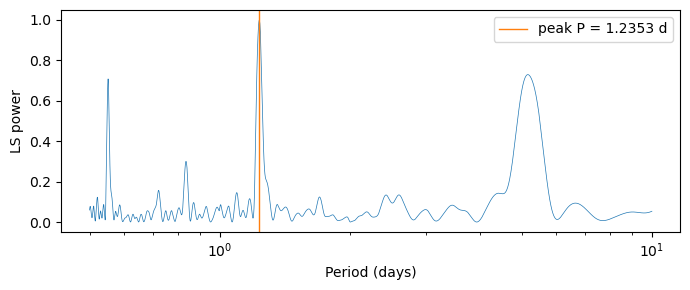

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import pyvartools as vt

lc = vt.LightCurve.from_file("EXAMPLES/2")
result = lc.LS(0.5, 10.0, 0.001, save_periodogram=True)

pgram = result.files["LS_periodogram_0"]
print(pgram.head())
print(f"shape: {pgram.shape}")

fig, ax = plt.subplots(figsize=(7, 3))
period = 1.0 / pgram[0]
ax.plot(period, pgram[1], lw=0.5)
ax.set_xscale("log")
ax.set_xlabel("Period (days)")
ax.set_ylabel("LS power")
ax.axvline(result.varobjs.LS.Period_1, color="C1", lw=1,
           label=f"peak P = {result.varobjs.LS.Period_1:.4f} d")
ax.legend()
fig.tight_layout()
fig.savefig("/tmp/ls_periodogram.png", dpi=100)

```text
          0         1            2
0  0.100009  0.053061 -2148.769221
1  0.100041  0.052929 -2147.068409
2  0.100074  0.052798 -2145.376696
3  0.100106  0.052668 -2143.694210
4  0.100138  0.052539 -2142.021078
shape: (59104, 3)
```

![LS periodogram of EXAMPLES/2](../assets/examples/ls_periodogram.png)

The DataFrame has 59 104 rows spanning 0.10–2.0 cycles/day. Column indices
are integers because the vartools periodogram file has no header row —
column 0 is frequency, column 1 is power, column 2 is log₁₀ false-alarm
probability.

---

## AoV on a light curve with an injected eclipsing-binary signal

Inject a realistic detached eclipsing-binary signal into `EXAMPLES/4` using
the JKTEBOP model (shipped as a USERLIB extension), then run three
period-finders on the result to compare how each responds to a non-sinusoidal
signal with two dips per orbit.

The injection uses a 1.7345 d orbit, a/(R₁+R₂) = 8 (so sum of fractional
radii r₁+r₂ = 0.125), R₂/R₁ = 0.8, mass ratio 0.8, surface-brightness ratio
J₂/J₁ = 0.25, central eclipses (`bimpact = 0`), circular orbit, and
quadratic limb darkening with coefficients (0.6, 0.2) on both stars.

### Command line

Shell variable `T0` is the first observation in `EXAMPLES/4` (53725.17392),
which we use as the reference epoch so the first primary eclipse lands at
the start of the light curve.

```bash
T0=53725.17392
./vartools \
    -L /home/jhartman/SVN/HATpipe/data/vartools/USERLIBS/jktebop.so \
    -i EXAMPLES/4 \
    -jktebop inject \
        Period fix 1.7345 T0 fix $T0 \
        r1+r2 fix 0.125 r2/r1 fix 0.8 M2/M1 fix 0.8 J2/J1 fix 0.25 \
        bimpact fix 0.0 esinomega fix 0.0 ecosomega fix 0.0 \
        LD1 quad fix 0.6 0.2 \
        LD2 quad fix 0.6 0.2 \
    -LS 0.5 10.0 0.0005 1 0 \
    -aov Nbin 100 0.5 10.0 0.1 0.001 1 0 \
    -aov_harm 50 0.5 10.0 0.1 0.001 1 0 \
    -oneline
```

`-aov` uses `Nbin 100` instead of the default 8 — more phase bins mean the
two narrow eclipses fall inside their own bins, instead of being diluted
into the sinusoid-scale bin grid. `-aov_harm` uses `Nharm = 50` — far more
harmonics than typical for a sinusoidal signal, but appropriate for the
sharp, narrow eclipse profile of an EB.

```text
Name                       = EXAMPLES/4
Jktebop_PERIOD_0           = 1.73450
Jktebop_T0_0               = 53725.17392
Jktebop_R1+R2_0            = 0.125
Jktebop_R2/R1_0            = 0.8
Jktebop_M2/M1_0            = 0.8
Jktebop_J2/J1_0            = 0.25
Jktebop_BIMPACT_0          = 0
Jktebop_INCLINATION_0      = 90
LS_Period_1_1              =     0.86992186
Log10_LS_Prob_1_1          =  -55.14150
LS_SNR_1_1                 =    4.80510
Period_1_2                 =     1.73441598
AOV_1_2                    =  487.90254
AOV_SNR_1_2                =   67.78358
Period_1_3                 =     1.73451269
AOV_HARM_1_3               =  5317.63
AOV_HARM_SNR_1_3           =   415.72
```

Lomb-Scargle finds the half-period harmonic (0.870 d) at SNR 4.8 because a
sinusoid at P/2 matches the symmetric primary-secondary structure about as
well as one at P. **Both AoV variants recover the true injected period
(1.7345 d)**. The higher bin/harmonic counts are the key: a
coarse model picks up the P/2 harmonic.

### Python

The typed `cmd.jktebop(...)` wrapper is auto-loaded from the installed
userlibs directory, so no `lib_path=` argument is needed in this example.

In [5]:
import pyvartools as vt
from pyvartools import commands as cmd

lc = vt.LightCurve.from_file("EXAMPLES/4")
T0 = float(lc.t.min())

result = (vt.Pipeline()
        .jktebop(
            "inject",
            Period=1.7345, T0=T0,
            r1_r2=0.125, r2_r1=0.8, M2_M1=0.8, J2_J1=0.25,
            bimpact=0.0, esinomega=0.0, ecosomega=0.0,
            LD1_law="quad", LD1_coeffs=(0.6, 0.2),
            LD2_law="quad", LD2_coeffs=(0.6, 0.2),
        )
        .LS(0.5, 10.0, 0.0005, npeaks=1)
        .aov(0.5, 10.0, 0.1, finetune=0.001, nbin=100, npeaks=1)
        .aov_harm(nharm=50, minp=0.5, maxp=10.0, subsample=0.1,
                 finetune=0.001, npeaks=1)).run(lc)

print(f"injected : 1.73450 d (P/2 = 0.86725 d)")
print(f"LS       : P={result.vars['LS_Period_1_1']:.5f} d   "
      f"SNR={result.vars['LS_SNR_1_1']:.2f}")
print(f"AoV      : P={result.vars['Period_1_2']:.5f} d   "
      f"SNR={result.vars['AOV_SNR_1_2']:.2f}")
print(f"AoV_harm : P={result.vars['Period_1_3']:.5f} d   "
      f"SNR={result.vars['AOV_HARM_SNR_1_3']:.2f}")

injected : 1.73450 d (P/2 = 0.86725 d)
LS       : P=0.86992 d   SNR=4.81
AoV      : P=1.73442 d   SNR=67.78
AoV_harm : P=1.73451 d   SNR=415.72


```text
injected : 1.73450 d (P/2 = 0.86725 d)
LS       : P=0.86992 d   SNR=4.80
AoV      : P=1.73442 d   SNR=67.78
AoV_harm : P=1.73451 d   SNR=415.72
```

The typed `jktebop` wrapper's attributes (`r1_r2`, `r2_r1`, `M2_M1`,
`J2_J1`) use underscores because `+` and `/` can't appear in Python
identifiers. The CLI-side `r1+r2`, `r2/r1`, etc. are emitted automatically.
`"inject"` mode is first-positional; the parameter defaults match the CLI's
`fix` keyword unless you pass `vary_Period=True` etc. to free them in a
fit (see the Model Fitting → `jktebop` command reference).

### Phase-folded at the AoV-recovered period

Inject, find the period, and phase-fold the light curve in one pipeline
using `-Phase`. The fold is placed on the AoV-recovered period (1.73442 d)
with a quarter-period T0 offset so the primary eclipse sits at phase −0.25
and the secondary at +0.25, giving each dip its own breathing room in a
[−0.5, 0.5] x-axis.

`-Phase` stores the per-point phase in the LC vector variable `ph` via
`phasevar`; `startphase -0.5` shifts the fold range from the default
[0, 1) to [−0.5, 0.5). The `T0` expression references the AoV
command's native `Period_1_1` output column. `myT0` is set via `-expr
listvar` so it's available in the `T0` expression. The variable `ph`
will be included in the captured output light curve, together with the
default variables `t`, `mag`, and `err`. Giving the `key="folded"`
option to `cmd.o()` allows access to the output light curve via
`result.files["folded"]`.

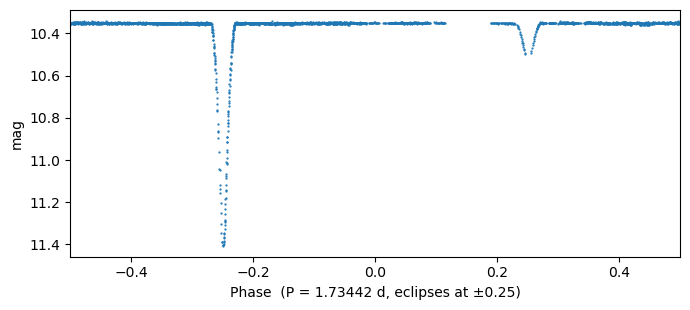

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import pyvartools as vt
from pyvartools import commands as cmd

lc = vt.LightCurve.from_file("EXAMPLES/4")
T0 = float(lc.t.min())

result = (vt.Pipeline()
        .jktebop(
            "inject",
            Period=1.7345, T0=T0,
            r1_r2=0.125, r2_r1=0.8, M2_M1=0.8, J2_J1=0.25,
            bimpact=0.0, esinomega=0.0, ecosomega=0.0,
            LD1_law="quad", LD1_coeffs=(0.6, 0.2),
            LD2_law="quad", LD2_coeffs=(0.6, 0.2),
        )
        .aov(0.5, 10.0, 0.1, finetune=0.001, nbin=100, npeaks=1)
        .expr(f"myT0={T0}", vartype="listvar")
        .Phase(period="aov",
              T0="expr myT0+0.25*Period_1_1",
              phasevar="ph",
              startphase=-0.5)
        .o(capture=True, key="folded")).run(lc)

P_aov = float(result.varobjs.aov.Period_1)
df = result.files["folded"].to_dataframe()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(df["ph"], df["mag"], ".", ms=1.2, color="C0")
ax.invert_yaxis()          # magnitude convention: brighter = lower y
ax.set_xlim(-0.5, 0.5)
ax.set_xlabel(f"Phase  (P = {P_aov:.5f} d, eclipses at ±0.25)")
ax.set_ylabel("mag")
fig.tight_layout()
fig.savefig("/tmp/eb_phased.png", dpi=120)

![EB-injected EXAMPLES/4 phased at the AoV period](../assets/examples/eb_phased.png)

The above script produces this plot.

---

## Notes

The `0` at the end of the `-LS` argument list disables periodogram output;
pass a directory path (or set `save_periodogram=True` in Python) to write the
frequency-power spectrum for plotting.

`-harmonicfilter` with `ls` picks up the top LS period from the prior command.
The three zeros after `ls` request fundamental-only (no harmonics, no
sub-harmonics, output the model LC with the best-fit sine in the third
column). The `EXAMPLES/OUTDIR1` argument is the directory where the model LC
is written as `EXAMPLES/OUTDIR1/2.harmonicfilter.model`.

`-oneline` reformats the one-row-per-LC default into one-statistic-per-line
— handy for single-LC runs.

Useful variants:

- Save a periodogram for plotting: replace the `0` after the peak count with
  `operiodogram EXAMPLES/OUTDIR1` in the CLI, or set
  `save_periodogram=True` in `cmd.LS(...)`. With `save_periodogram=True`
  the periodogram is available as a DataFrame via
  `result.files["LS_periodogram_0"]`.
- Report more peaks: change the `1` after the frequency step (and
  `npeaks=1`) to a larger number; the output columns become
  `LS_Period_1_0` through `LS_Period_N_0`.
- AoV / multi-harmonic AoV: swap `-LS` for `-aov` or `-aov_harm NHARM`; the
  rest of the pipeline is identical.
- For some non-sinusoidal signals, `-aov_harm` can recover
  periods more reliably than Lomb-Scargle.
- Sigma-clip first to stop outliers from dominating the periodogram:
  prepend `-clip 5.0 1` (CLI) or `cmd.clip(5.0, iterative=True)` (Python).

---

## Transit Injection


# Transit injection

Generate a Mandel-Agol transit model for a light curve with all parameters
fixed. The model is written to `OUTDIR1/3.mandelagoltransit.model`; adding
that signal to the original LC produces a realistic noisy transit LC suitable
for recovery tests (see the
[transit search & fit](transit-search-and-fit.md) example).

## Command line

```bash
./vartools -i EXAMPLES/3 \
    -MandelAgolTransit 2.12345 53725.174 0.1 10.0 i 90.0 0. 0. 0 \
        quad 0.236 0.391 \
        0 0 0 0 0 0 0 0 0 0 0 1 EXAMPLES/OUTDIR1 \
    -header

gawk '{print $1, $2 + $3, $4}' \
    EXAMPLES/OUTDIR1/3.mandelagoltransit.model > EXAMPLES/3.transit
```

```text
#Name MandelAgolTransit_Period_0 MandelAgolTransit_T0_0 MandelAgolTransit_r_0 \
MandelAgolTransit_a_0 MandelAgolTransit_bimpact_0 MandelAgolTransit_inc_0 \
MandelAgolTransit_e_0 MandelAgolTransit_omega_0 MandelAgolTransit_mconst_0 \
MandelAgolTransit_ldcoeff1_0 MandelAgolTransit_ldcoeff2_0 \
MandelAgolTransit_chi2_0
EXAMPLES/3  2.12345000 53725.17400000   0.10000  10.00000   0.00000  90.00000 \
  0.00000   0.00000   0.00000   0.23600   0.39100 129730808.07162
```

## Python

In [7]:
import pyvartools as vt
from pyvartools import commands as cmd

lc = vt.LightCurve.from_file("EXAMPLES/3")

result = (vt.Pipeline()
        .MandelAgolTransit(
            P0=2.12345, T00=53725.174, r0=0.1, a0=10.0, inclination=90.0,
            e0=0.0, omega0=0.0, mconst0=0.0,
            ld_type="quad", ld_coeffs=[0.236, 0.391],
            fitephem=0, fitr=0, fita=0, fitinclterm=0, fite=0, fitomega=0,
            fitmconst=0, fitldcoeffs=[0, 0],
            correct_lc=False,
            save_model=True,
        )).run(lc)

print(result.vars)

Name                                          3
MandelAgolTransit_Period_0              2.12345
MandelAgolTransit_T0_0                53725.174
MandelAgolTransit_r_0                       0.1
MandelAgolTransit_a_0                      10.0
MandelAgolTransit_bimpact_0                 0.0
MandelAgolTransit_inc_0                    90.0
MandelAgolTransit_e_0                       0.0
MandelAgolTransit_omega_0                   0.0
MandelAgolTransit_mconst_0                  0.0
MandelAgolTransit_ldcoeff1_0              0.236
MandelAgolTransit_ldcoeff2_0              0.391
MandelAgolTransit_chi2_0        129730808.07162
Name: 0, dtype: object


```text
Name                                          3
MandelAgolTransit_Period_0              2.12345
MandelAgolTransit_T0_0                53725.174
MandelAgolTransit_r_0                       0.1
MandelAgolTransit_a_0                      10.0
MandelAgolTransit_bimpact_0                 0.0
MandelAgolTransit_inc_0                    90.0
MandelAgolTransit_e_0                       0.0
MandelAgolTransit_omega_0                   0.0
MandelAgolTransit_mconst_0                  0.0
MandelAgolTransit_ldcoeff1_0              0.236
MandelAgolTransit_ldcoeff2_0              0.391
MandelAgolTransit_chi2_0        129730808.07162
```

## Notes

Parameters passed to `-MandelAgolTransit`: period 2.12345 d, T0 = 53725.174,
Rp/R* = 0.1, a/R* = 10.0, inclination 90 degrees (transit central), circular
orbit, quadratic limb darkening with coefficients (0.236, 0.391). The long
run of zeros are the `fitephem fitr fita fitinclterm fite fitomega fitmconst
fitldcoeff1 fitldcoeff2 fitRV correctlc` flags; everything is held fixed and
the LC is not corrected. The final `1 EXAMPLES/OUTDIR1` writes the model to
disk.

The CLI pipeline writes only the model, so a second step (`gawk` in the
original example, or `-Injecttransit` if you want a single-call workflow) is
needed to add that model onto the observed LC and save the result to
`EXAMPLES/3.transit`, which the next example uses as its input.

### Variation: one-step injection with `-Injecttransit`

`-Injecttransit` creates a noisy transit LC in a single step without the
external `gawk` call. It takes physical parameters (Rp, Mp, Mstar, Rstar)
rather than a/R*, and it adds the model to the LC in-place:

```bash
./vartools -i EXAMPLES/3 \
    -Injecttransit fix 2.12345 Rpfix 0.1 Mpfix 0.001 phasefix 0.0 \
        sinifix 1.0 eomega efix 0 ofix 0 Mstarfix 1.0 Rstarfix 1.0 \
        quad 0.236 0.391 0 \
    -o EXAMPLES/3.transit \
    -header
```

The Python equivalent uses `cmd.Injecttransit(...)` followed by `cmd.o(...)`.

---

## Transit Search And Fit


# Transit search and fit

Detrend with TFA and then search for transits with BLS using a trapezoidal
in-transit fit. The input is `EXAMPLES/3.transit`, the LC created by the
[transit injection](transit-injection.md) example.

## Command line

```bash
./vartools -l EXAMPLES/lc_list_tfa \
    -rms \
    -TFA EXAMPLES/trendlist_tfa EXAMPLES/dates_tfa 25.0 1 0 0 \
    -BLS density 1.41 0.5 2.0 0.5 5.0 optimal 0.1 200 7 2 0 1 EXAMPLES/OUTDIR1 1 fittrap \
    -rms \
    -oneline
```

```text
Name                         = EXAMPLES/3.transit
Mean_Mag_0                   =  10.16727
RMS_0                        =   0.00542
Expected_RMS_0               =   0.00104
Npoints_0                    =  3417
TFA_MeanMag_1                =  10.16714
TFA_RMS_1                    =   0.00471
BLS_Period_1_2               =     2.12402761
BLS_Tc_1_2                   = 53727.294878968052
BLS_SN_1_2                   =  69.00454
BLS_SDE_1_2                  =   4.41122
BLS_Depth_1_2                =   0.01186
BLS_Qtran_1_2                =   0.03586
BLS_Qingress_1_2             =   0.16670
BLS_Npointsintransit_1_2     =   161
BLS_Ntransits_1_2            =     4
BLS_SignaltoPinknoise_1_2    =  15.93733
BLS_Period_2_2               =     1.35229047
...
RMS_3                        =   0.00405
```

## Python

In [8]:
import pyvartools as vt
from pyvartools import commands as cmd

pipe = (vt.Pipeline()
        .rms()
        .TFA(
            trendlist="EXAMPLES/trendlist_tfa",
            dates_file="EXAMPLES/dates_tfa",
            pixelsep=25.0,
            correct_lc=True,
            save_coeffs=False,
            save_model=False,
        )
        .BLS(
            density_mode=True,
            stellar_density=1.41,        # solar density, g/cm³
            min_exp_dur_frac=0.5,
            max_exp_dur_frac=2.0,
            minper=0.5, maxper=5.0,
            subsample=0.1,               # oversampling for "optimal" grid
            nbins=200,
            timezone=7, npeaks=2,
            save_periodogram=False,
            correct_lc=True,
            fittrap=True,
        )
        .rms())

result = pipe.run_filelist("EXAMPLES/lc_list_tfa")

row = result.vars.iloc[0]
for col in ["RMS_0", "TFA_RMS_1", "BLS_Period_1_2", "BLS_Tc_1_2",
            "BLS_SN_1_2", "BLS_SDE_1_2", "BLS_Depth_1_2",
            "BLS_Qtran_1_2", "BLS_SignaltoPinknoise_1_2",
            "BLS_Period_2_2", "RMS_3"]:
    print(f"{col:<30} = {row[col]}")

RMS_0                          = 0.00542
TFA_RMS_1                      = 0.00471
BLS_Period_1_2                 = 2.12402761
BLS_Tc_1_2                     = 53727.29487896805
BLS_SN_1_2                     = 69.00454
BLS_SDE_1_2                    = 4.41122
BLS_Depth_1_2                  = 0.01186
BLS_Qtran_1_2                  = 0.03586
BLS_SignaltoPinknoise_1_2      = 15.93733
BLS_Period_2_2                 = 1.35229047
RMS_3                          = 0.00405


```text
RMS_0                          = 0.00542
TFA_RMS_1                      = 0.00471
BLS_Period_1_2                 = 2.12402761
BLS_Tc_1_2                     = 53727.29487896805
BLS_SN_1_2                     = 69.00454
BLS_SDE_1_2                    = 4.41122
BLS_Depth_1_2                  = 0.01186
BLS_Qtran_1_2                  = 0.03586
BLS_SignaltoPinknoise_1_2      = 15.93733
BLS_Period_2_2                 = 1.35229047
RMS_3                          = 0.00405
```

## Notes

`-TFA` fits a linear combination of template trend light curves to remove
shared systematics. The template list is `EXAMPLES/trendlist_tfa` (paths +
pixel coordinates for each star); `EXAMPLES/dates_tfa` is the global cadence
file. The `25.0` is the minimum pixel separation between target and template
— templates within 25 pixels of `EXAMPLES/3.transit` are excluded, so the
target's own signal can't leak back into the detrending model. The three
final flags are `correctlc=1 save_coeffs=0 save_model=0`.

`-BLS` then searches for transits on the detrended LC:

- `density 1.41 0.5 2.0` — stellar density (g/cm³) plus min/max fractional
  scaling of the expected transit duration; BLS computes the per-trial-period
  duration bounds from the density assuming a circular orbit.
- `0.5 5.0` — period range in days.
- `optimal 0.1` — optimal frequency grid with a subsampling factor of 0.1
  (finer than the native optimal spacing by 10×).
- `200` — phase bins.
- `7` — local timezone offset in hours (used for the one-night-fraction
  statistic).
- `2` — number of peaks to report.
- `0 1 EXAMPLES/OUTDIR1` — skip periodogram output, write the BLS model LC
  to the output dir.
- `1 fittrap` — subtract the best-fit box before passing to the next
  command, and fit a trapezoidal transit at each peak (which adds the
  `Qingress` and `OOTmag` columns).

The final `-rms` captures the residual scatter after the transit model is
subtracted. For this LC the RMS drops from 0.00542 mag (raw) to 0.00471 mag
(post-TFA) to 0.00405 mag (post-TFA + transit removal). The best BLS period,
2.12403 d, matches the injected 2.12345 d; the 1.352 d secondary peak is a
harmonic alias.

`BLS_SignaltoPinknoise` is the most useful single-statistic indicator for
transit candidates; values above ~10 are strong candidates once the LC has
been properly detrended.

### Variation: Mandel-Agol fit at the BLS period

After BLS finds a candidate, we seed a Mandel-Agol physical transit fit
with the BLS period, transit center, depth, and fractional duration; the
initial impact parameter is 0.1. `ophcurve` writes the fitted model as a
phase curve from −0.5 to 0.5 so it can be overplotted directly on the
folded observations.

```bash
./vartools -i EXAMPLES/3.transit \
    -BLS density 1.41 0.5 2.0 0.5 5.0 optimal 0.1 200 7 1 0 0 0 fittrap \
    -MandelAgolTransit \
        expr BLS_Period_1_0 expr BLS_Tc_1_0 \
        expr 'sqrt(BLS_Depth_1_0)' expr '1.0/(BLS_Qtran_1_0*pi)' \
        b 0.1 0.0 0.0 -1 quad 0.3 0.3 \
        1 1 1 1 0 0 1 0 0 0 0 0 \
        ophcurve EXAMPLES/OUTDIR1 -0.5 0.5 0.001 \
    -oneline
```

`expr BLS_Period_1_0` etc. pull the BLS outputs from the prior command
into the MA init values; `b 0.1` initializes the impact parameter (which
is what the fit varies, via `fitinclterm=1`). `mconst0 = -1` tells
vartools to estimate the out-of-transit magnitude from the light curve.

```text
Name                         = EXAMPLES/3.transit
BLS_Period_1_0               =     2.12402761
BLS_Tc_1_0                   = 53727.294970417119
BLS_SN_1_0                   =  66.76648
BLS_SDE_1_0                  =   4.34232
BLS_Depth_1_0                =   0.01139
BLS_Qtran_1_0                =   0.03603
BLS_SignaltoPinknoise_1_0    =  13.48275
...
MandelAgolTransit_Period_1   =     2.12339179
MandelAgolTransit_T0_1       = 53727.29676768
MandelAgolTransit_r_1        =   0.09810
MandelAgolTransit_a_1        =   9.66412
MandelAgolTransit_bimpact_1  =   0.27251
MandelAgolTransit_inc_1      =  88.38413
MandelAgolTransit_mconst_1   =  10.16686
MandelAgolTransit_chi2_1     =  27.06389
```

The Python equivalent mirrors the CLI: expressions reference the BLS
output columns, `bimpact=0.1` is the initial impact parameter, and
`save_phcurve=True` with `ophcurve_phmin/phmax/phstep` captures the
fitted model as a DataFrame. A `cmd.Phase(...)` step after the fit
folds the observations on the MA-optimized ephemeris and stores the
per-point phase in a new LC vector `ph_obs`, which is picked up directly
by `cmd.o(capture=True)`.

P        = 2.12339179
T0       = 53727.29676768
r        = 0.0981
a/R*     = 9.66412
bimpact  = 0.27251
inc      = 88.38413
mconst   = 10.16686
chi2     = 27.06389


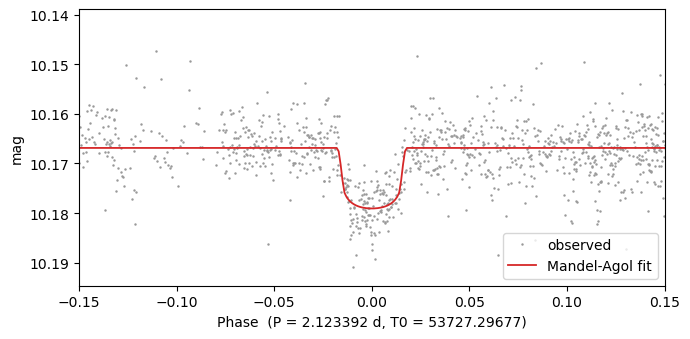

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import pyvartools as vt
from pyvartools import commands as cmd

lc = vt.LightCurve.from_file("EXAMPLES/3.transit")

result = (vt.Pipeline()
        .BLS(
            density_mode=True, stellar_density=1.41,
            min_exp_dur_frac=0.5, max_exp_dur_frac=2.0,
            minper=0.5, maxper=5.0,
            subsample=0.1, nbins=200,
            timezone=7, npeaks=1,
            save_periodogram=False, correct_lc=False, fittrap=True,
        )
        .MandelAgolTransit(
            P0="expr BLS_Period_1_0",
            T00="expr BLS_Tc_1_0",
            r0="expr sqrt(BLS_Depth_1_0)",
            a0="expr 1.0/(BLS_Qtran_1_0*pi)",
            bimpact=0.1,
            mconst0=-1,                  # let vartools estimate the baseline
            ld_coeffs=[0.3, 0.3],
            fitephem=1, fitr=1, fita=1, fitinclterm=1,
            fite=0, fitomega=0, fitmconst=1, fitldcoeffs=[0, 0],
            save_phcurve=True,
            ophcurve_phmin=-0.5, ophcurve_phmax=0.5, ophcurve_phstep=0.001,
        )
        .Phase(
            period="fixcolumn MandelAgolTransit_Period_1",
            T0="fixcolumn MandelAgolTransit_T0_1",
            phasevar="ph_obs",
            startphase=-0.5,
        )
        .o(capture=True, key="folded")).run(lc)

fit    = result.varobjs.MandelAgolTransit
folded = result.files["folded"].to_dataframe()
model  = result.files["MandelAgolTransit_phcurve_1"]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(folded["ph_obs"], folded["mag"], ".", ms=1.5,
        color="0.6", label="observed")
ax.plot(model[0], model[1], "-", lw=1.3,
        color="C3", label="Mandel-Agol fit")
ax.set_xlim(-0.15, 0.15)
ax.invert_yaxis()
P, T0 = float(fit.Period), float(fit.T0)
ax.set_xlabel(f"Phase  (P = {P:.6f} d, T0 = {T0:.5f})")
ax.set_ylabel("mag")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("/tmp/mandel_agol_fit.png", dpi=120)

for name, val in [("P", float(fit.Period)),
                  ("T0", float(fit.T0)),
                  ("r", float(fit.r)),
                  ("a/R*", float(fit.a)),
                  ("bimpact", float(fit.bimpact)),
                  ("inc", float(fit.inc)),
                  ("mconst", float(fit.mconst)),
                  ("chi2", float(fit.chi2))]:
    print(f"{name:<8} = {val}")

```text
P        = 2.12339179
T0       = 53727.29676768
r        = 0.0981
a/R*     = 9.66412
bimpact  = 0.27251
inc      = 88.38413
mconst   = 10.16686
chi2     = 27.06389
```

![Mandel-Agol transit fit on EXAMPLES/3.transit](../assets/examples/mandel_agol_fit.png)

The fitted period (2.12339 d) shifts by ~0.9 minutes from the BLS grid
value (2.12403 d) and the fitted T0 (BJD 53727.29677) by ~2.6 minutes
from the BLS transit centre. The red curve is the Mandel-Agol model
written by `ophcurve` (directly on a [−0.5, 0.5] phase grid); the gray
points are the observations folded on the fitted ephemeris via
`cmd.Phase(..., phasevar="ph_obs", startphase=-0.5)`.

# Phase-fold the (untransformed) LC at the fitted Mandel-Agol ephemeris.
out = result.lc
ph = ((out.t - T0) / P)
ph -= np.floor(ph)
ph[ph > 0.5] -= 1.0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ph, out.mag, ".", ms=2, color="0.4")
ax.set_xlim(-0.15, 0.15)
ax.invert_yaxis()
ax.set_xlabel(f"Phase  (P = {P:.6f} d, T0 = {T0:.5f})")
ax.set_ylabel("mag")
ax.set_title("CETRA → BLSFixPerDurTc → Mandel-Agol")
fig.tight_layout()
fig.savefig("/tmp/cetra_transit_fold.png", dpi=120)
```text

```
CETRA period         = 2.123535 d
Mandel-Agol P        = 2.123393 d
Mandel-Agol T0       = 53727.29676
Mandel-Agol r        = 0.09774
Mandel-Agol a/R*     = 9.9821
Mandel-Agol inc      = 89.153 deg
Mandel-Agol chi2     = 27.065
# Phase-fold the (already detrended) LC at the fitted ephemeris.
```text

![CETRA → Mandel-Agol fit on EXAMPLES/3.transit](../assets/examples/cetra_transit_fold.png)

CETRA's grid period (2.1235 d) is within ~10 s of the Mandel-Agol fitted period (2.12339 d) — close enough that `BLSFixPerDurTc` finds the transit cleanly, and the subsequent Mandel-Agol fit produces parameters consistent with the BLS-seeded variant above (r = 0.098, a/R* = 9.98, i = 89.15°).

out = result.lc
ph = ((out.t - T0) / P)
ph -= np.floor(ph)
ph[ph > 0.5] -= 1.0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ph, out.mag, ".", ms=2, color="0.4")
ax.set_xlim(-0.15, 0.15)
ax.invert_yaxis()
ax.set_xlabel(f"Phase  (P = {P:.6f} d, T0 = {T0:.5f})")
ax.set_ylabel("mag (after high-pass)")
ax.set_title("harmonicfilter (P=10d, nsubharm=10) → CETRA → Mandel-Agol")
fig.tight_layout()
fig.savefig("/tmp/cetra_highpass_transit_fold.png", dpi=120)
```

```text
CETRA period         = 2.123535 d
Mandel-Agol P        = 2.123408 d
Mandel-Agol T0       = 53727.29540
Mandel-Agol r        = 0.09268
Mandel-Agol a/R*     = 10.3707
Mandel-Agol inc      = 89.097 deg
Mandel-Agol chi2     = 26.148
```

![High-pass + CETRA + Mandel-Agol on EXAMPLES/3.transit](../assets/examples/cetra_highpass_transit_fold.png)

The high-pass step removes a small amount of long-timescale structure that BLS-style searches typically don't care about but that can bias a model fit; here the χ² drops modestly from 27.1 to 26.1, and the fitted radius / a /inclination shift by a fraction of their per-fit uncertainties — consistent with the picture that the input LC was already mostly clean.

---

## Rrlyrae Recovery


# RR Lyrae recovery

Inject a realistic RR Lyrae signal — a Fourier series fit to the M3 V006
light curve — at a grid of amplitudes into a clean LC and see how low the
amplitude can go before Lomb-Scargle and multi-harmonic AoV fail to recover
the period.

## Command line

### Step 1: fit a Fourier series to the template RR Lyrae

```bash
./vartools -i EXAMPLES/M3.V006.lc \
    -harmonicfilter fix 1 0.514333 10 0 1 EXAMPLES/OUTDIR1/ fitonly outRphi \
    -header
```

```text
#Name HarmonicFilter_Mean_Mag_0 HarmonicFilter_Period_1_0 \
HarmonicFilter_Per1_Fundamental_Amp_0 HarmonicFilter_Per1_Fundamental_Phi_0 \
HarmonicFilter_Per1_Harm_R_2_1_0 HarmonicFilter_Per1_Harm_Phi_2_1_0 ... \
HarmonicFilter_Per1_Amplitude_0
EXAMPLES/M3.V006.lc  15.77123 0.51433300 0.38041 -0.07662 \
0.47077 0.60826 0.35917 0.26249 0.23631 -0.06843 0.16353 0.60682 \
0.10621 0.28738 0.06203 0.95751 0.03602 0.58867 0.02900 0.22322 \
0.01750 0.94258 0.00768 0.66560 1.11128
```

### Step 2: inject at 10 halving amplitudes and try to recover

```bash
echo EXAMPLES/4 \
  | gawk '{amp=0.25; for(i=1;i<=10;i++){print $1,amp; amp=amp*0.5;}}' \
  | ./vartools -l - \
      -Injectharm fix 0.514333 10 \
         amplist phaserand \
         ampfix 0.47077 amprel phasefix 0.60826 phaserel \
         ampfix 0.35916 amprel phasefix 0.26249 phaserel \
         ampfix 0.23631 amprel phasefix -0.06843 phaserel \
         ampfix 0.16353 amprel phasefix 0.60682 phaserel \
         ampfix 0.10621 amprel phasefix 0.28738 phaserel \
         ampfix 0.06203 amprel phasefix 0.95751 phaserel \
         ampfix 0.03602 amprel phasefix 0.58867 phaserel \
         ampfix 0.02900 amprel phasefix 0.22322 phaserel \
         ampfix 0.01750 amprel phasefix 0.94258 phaserel \
         ampfix 0.00768 amprel phasefix 0.66560 phaserel \
         0 0 \
      -LS 0.1 10.0 0.01 2 0 \
      -aov_harm 2 0.1 10.0 0.1 0.01 2 0 \
      -header -numbercolumns
```

```text
#1_Name 2_Injectharm_Period_0 3_Injectharm_Fundamental_Amp_0 ... \
25_LS_Period_1_1 26_Log10_LS_Prob_1_1 27_LS_Periodogram_Value_1_1 ... \
33_Period_1_2 34_AOV_HARM_1_2 ...
EXAMPLES/4 0.51433300 0.25000 ... 0.51501823 -862.16710 0.70931 ... \
  0.51432840 4322.49 149.531 2969.03 ...
EXAMPLES/4 0.51433300 0.12500 ... 0.51408199 -846.91348 0.70291 ... \
  0.51432840 4609.61 137.471 3056.79 ...
...
EXAMPLES/4 0.51433300 0.00098 ... 0.99479057 -101.16218 0.13799 ... \
  1.99136298 166.558 9.40744 291.44 ...
EXAMPLES/4 0.51433300 0.00049 ... 0.99415471 -118.90869 0.15957 ... \
  0.99348763 199.742 13.8977 345.37 ...
```

## Python

# Step 1: fit a Fourier series to the template RR Lyrae light curve
# Pull the R_k1 and phi_k1 coefficients from the fit
# Step 2: inject at 10 halving amplitudes and try to recover.
# Injectharm's harmonic_amps_rel / harmonic_phases_rel kwargs emit the
# ampfix/amprel + phasefix/phaserel pair per harmonic, scaling each
# overtone relative to the fundamental.

In [10]:
import pyvartools as vt
from pyvartools import commands as cmd
import pandas as pd

tmpl = vt.LightCurve.from_file("EXAMPLES/M3.V006.lc")
fit = (vt.Pipeline()
        .harmonicfilter(
            period=0.514333,
            nharm=10,
            nsubharm=0,
            save_model=True,
            fitonly=True,
            output_format="outRphi",
        )).run(tmpl)

row = fit.vars
Rphi = []
for k in range(2, 12):  # harmonic indices 2..11
    R = float(row[f"HarmonicFilter_Per1_Harm_R_{k}_1_0"])
    phi = float(row[f"HarmonicFilter_Per1_Harm_Phi_{k}_1_0"])
    Rphi.append((R, phi))

amps_rel = [R for R, _ in Rphi]
phases_rel = [phi for _, phi in Rphi]

rows = []
for i in range(10):
    amp = 0.25 * (0.5 ** i)

    lc = vt.LightCurve.from_file("EXAMPLES/4")
    result = (vt.Pipeline()
            .Injectharm(period=0.514333, amplitude=amp, phase="rand",
                        nharm=11,
                        harmonic_amps_rel=amps_rel,
                        harmonic_phases_rel=phases_rel)
            .LS(0.1, 10.0, 0.01, npeaks=2, save_periodogram=False)
            .aov_harm(nharm=2, minp=0.1, maxp=10.0, subsample=0.1,
                     finetune=0.01, npeaks=2, save_periodogram=False)).run(lc)

    rows.append({
        "inj_amp": amp,
        "LS_P1": float(result.vars["LS_Period_1_1"]),
        "LS_logFAP_1": float(result.vars["Log10_LS_Prob_1_1"]),
        "AOVh_P1": float(result.vars["Period_1_2"]),
        "AOVh_SNR_1": float(result.vars["AOV_HARM_SNR_1_2"]),
    })

print(pd.DataFrame(rows).to_string(index=False))

 inj_amp    LS_P1  LS_logFAP_1  AOVh_P1  AOVh_SNR_1
0.250000 0.515018   -862.16080 0.514328    149.5270
0.125000 0.515018   -858.95995 0.514328    149.0430
0.062500 0.515018   -851.68826 0.514328    147.6330
0.031250 0.515018   -833.92591 0.514328    143.2020
0.015625 0.514933   -788.14344 0.514328    128.0760
0.007812 0.514933   -673.82770 0.514328     96.0964
0.003906 1.067872   -463.55764 0.514328     51.9892
0.001953 1.067872   -260.69320 0.514243     23.2312
0.000977 1.069340   -118.56042 0.513988     11.2327
0.000488 1.169000    -88.47821 2.326459     10.9564


```text
 inj_amp    LS_P1  LS_logFAP_1  AOVh_P1  AOVh_SNR_1
0.250000 0.515018   -862.16080 0.514328    149.5270
0.125000 0.515018   -858.95995 0.514328    149.0430
0.062500 0.515018   -851.68826 0.514328    147.6330
0.031250 0.515018   -833.92591 0.514328    143.2020
0.015625 0.514933   -788.14344 0.514328    128.0760
0.007812 0.514933   -673.82770 0.514328     96.0964
0.003906 1.067872   -463.55764 0.514328     51.9892
0.001953 1.067872   -260.69320 0.514243     23.2312
0.000977 1.069340   -118.56042 0.513988     11.2327
0.000488 1.169000    -88.47821 2.326459     10.9564
```

## Notes

Step 1 freezes the period at the known value (0.514333 d) and fits 10
harmonics. The `outRphi` keyword returns the Fourier coefficients as
`R_k1 = A_k / A_1` and `phi_k1 = phi_k - k*phi_1`, which is the natural
representation for reinjecting the same shape at a different amplitude.

Step 2 pipes a two-column stream (`name amp`) into vartools via `-l -`.
`-Injectharm` consumes the amplitude via `amplist` (second column of the
input list) for the fundamental, and reinjects the 10 harmonics with their
`R_k1` and `phi_k1` coefficients fixed and flagged `amprel` / `phaserel`
(so harmonic amplitude = R_k1 * amp_fundamental, and harmonic phase =
k*phi_fundamental + phi_k1). The fundamental phase is randomised by
`phaserand`.

Both LS and multi-harmonic AoV are run on each injected LC. AoV is better
suited to non-sinusoidal signals: it recovers the correct period down to
about 2 mmag fundamental amplitude (~5.7 mmag peak-to-peak), while LS starts
to fail around 4 mmag fundamental. The exact amplitude threshold where
recovery fails will vary run-to-run because the injection phase is random;
add `-randseed time` to the CLI (or use a fixed seed) if you want
reproducible runs.

The injection uses the `harmonic_amps_rel` / `harmonic_phases_rel` kwargs
on `cmd.Injectharm` to scale each overtone relative to the fundamental
amplitude — equivalent to the CLI's `ampfix R amprel phasefix phi
phaserel` per-harmonic block.

---

## Batch Variability


# Batch variability search

Run a battery of variability-selection algorithms — LS, AoV, multi-harmonic
AoV, BLS, autocorrelation — on a list of light curves using four threads in
parallel. Save and restore LC states let us chain differently-clipped copies
through different algorithms without losing points.

## Command line

```bash
./vartools -l EXAMPLES/lc_list -parallel 4 \
    -savelc \
    -clip 5.0 1 \
    -savelc \
    -LS 0.1 100.0 0.1 3 0 clip 5.0 1 \
    -aov 0.1 100.0 0.1 0.01 1 0 clip 5.0 1 \
    -aov_harm 1 0.1 100.0 0.1 0.01 1 0 clip 5.0 1 \
    -restorelc 1 \
    -clip 10.0 1 \
    -BLS q 0.01 0.1 0.1 20. 10000 200 7 2 0 0 0 \
    -restorelc 2 \
    -changeerror \
    -autocorrelation 0.0 30.0 0.1 EXAMPLES/OUTDIR1/ \
    -header
```

```text
#Name Nclip_1 LS_Period_1_3 ... Period_1_4 AOV_1_4 ... \
BLS_Period_1_8 BLS_SignaltoPinknoise_1_8 ... RMS_10
EXAMPLES/2   0  1.23440877 ... 1.23583047  9274.25316 ... \
 4.94437027  8.09875 ... 0.03663
EXAMPLES/4   6  0.99383709 ... 34.70790113   92.61914 ... \
 2.32488927  7.53376 ... 0.00204
EXAMPLES/1   0 77.76775250 ... 34.52470117 46218.43332 ... \
 3.05219780  6.02552 ... 0.15944
...
```

(Full output has 60+ columns per LC and 10 rows — one per input LC. Output
row order depends on which thread finishes first.)

## Python

In [11]:
import pyvartools as vt
from pyvartools import commands as cmd

lcs = [vt.LightCurve.from_file(f"EXAMPLES/{i}") for i in range(1, 11)]

pipeline = (vt.Pipeline()
        .savelc()
        .clip(5.0, iterative=True)
        .savelc()
        .LS(0.1, 100.0, 0.1, npeaks=3, save_periodogram=False,
           clip=5.0, clipiter=1)
        .aov(minp=0.1, maxp=100.0, subsample=0.1, finetune=0.01,
            npeaks=1, save_periodogram=False, clip=5.0, clipiter=1)
        .aov_harm(nharm=1, minp=0.1, maxp=100.0, subsample=0.1,
                 finetune=0.01, npeaks=1, save_periodogram=False,
                 clip=5.0, clipiter=1)
        .restorelc(1)
        .clip(10.0, iterative=True)
        .BLS(qmin=0.01, qmax=0.1, minper=0.1, maxper=20.0,
            nfreq=10000, nbins=200, timezone=7, npeaks=2,
            save_periodogram=False)
        .restorelc(2)
        .changeerror()
        .autocorrelation(start=0.0, stop=30.0, step=0.1,
                        save_result="EXAMPLES/OUTDIR1/"))

batch = pipeline.run_batch(lcs, nthreads=4)

print(batch.vars[["Name", "LS_Period_1_3", "Period_1_4",
                  "BLS_Period_1_8", "BLS_SignaltoPinknoise_1_8",
                  "RMS_10"]].to_string(index=False))

Name  LS_Period_1_3  Period_1_4  BLS_Period_1_8  BLS_SignaltoPinknoise_1_8  RMS_10
   1      77.767753   34.524701        3.052198                    6.02552 0.15944
   2       1.234409    1.235830        4.944370                    8.09875 0.03663
   3      18.298295   17.564611       16.407942                    4.03820 0.00486
   4       0.993837   34.707901        2.324889                    7.53376 0.00204
   5       7.069796    8.376121       20.000000                    3.29551 0.00287
   6      22.219358   22.855895        0.372989                    6.03064 0.00208
   7       0.147471    1.806541        3.637786                    7.13566 0.00348
   8       0.936961   12.290390        3.732363                    4.79817 0.00225
   9       7.069796    6.973107        7.485682                    4.85598 0.00187
  10       0.969069   22.249379        0.373128                    5.87482 0.00236


```text
Name  LS_Period_1_3  Period_1_4  BLS_Period_1_8  BLS_SignaltoPinknoise_1_8  RMS_10
   1      77.767753   34.524701        3.052198                    6.02552 0.15944
   2       1.234409    1.235830        4.944370                    8.09875 0.03663
   3      18.298295   17.564611       16.407942                    4.03820 0.00486
   4       0.993837   34.707901        2.324889                    7.53376 0.00204
   5       7.069796    8.376121       20.000000                    3.29551 0.00287
   6      22.219358   22.855895        0.372989                    6.03064 0.00208
   7       0.147471    1.806541        3.637786                    7.13566 0.00348
   8       0.936961   12.290390        3.732363                    4.79817 0.00225
   9       7.069796    6.973107        7.485682                    4.85598 0.00187
  10       0.969069   22.249379        0.373128                    5.87482 0.00236
```

## Notes

The pipeline uses two nested `savelc` states. State 1 is the raw LC; state 2
is the 5-sigma clipped version. After running LS/AoV/AoV-harm (each with
its own internal 5-sigma clip), `-restorelc 1` brings back the raw LC,
`-clip 10.0 1` applies a looser clip (aggressive clipping can remove the
very transits BLS is looking for), and BLS runs on that. `-restorelc 2`
then returns to the 5-sigma-clipped LC for the autocorrelation analysis,
which first needs the per-point errors replaced with the light curve RMS
via `-changeerror`.

Parallelism uses vartools' built-in `-parallel N` for the CLI and the
`nthreads=N` argument to `Pipeline.run_batch(...)` in Python. No external
`pexec`, `ProcessPoolExecutor`, or shell wrappers are needed. Output rows
are written in the order threads finish, so the `Name` column identifies
each row — pandas `sort_values` is convenient if you want a deterministic
row order.

`EXAMPLES/2` is a recognisable LS detection (period 1.234 d), `EXAMPLES/4`
yields a strong BLS candidate at 2.32 d (the transit injected in the
transit-injection example has been clipped slightly by the 10-sigma clip
so the period is off by a factor of two from the true 2.12 d — the second
BLS peak would catch it), and `EXAMPLES/1` has its RMS dominated by the
quadratic trend, which shows up as a long LS period near 78 d.
`EXAMPLES/OUTDIR1/2.autocorr` — the autocorrelation function for LC 2 —
shows a clear first peak at 1.23 d.

---

## Kepler Fits


# Kepler FITS

Read a Kepler FITS long-cadence light curve directly, convert flux to
magnitude, and run a Lomb-Scargle search. Demonstrates `-inputlcformat`
with FITS column selection, `-changevariable` to remap FITS column names
onto the standard `mag`/`err` variables, and `-fluxtomag` for the
flux-to-magnitude conversion.

The file `EXAMPLES/kplr000757076-2009166043257_llc.fits` is a Q1 Kepler
light curve stored as a FITS binary table.

## Command line

```bash
./vartools -i EXAMPLES/kplr000757076-2009166043257_llc.fits \
    -inputlcformat t:1,pdcsap_flux:8,pdcsap_flux_err:9 \
    -changevariable mag pdcsap_flux \
    -changevariable err pdcsap_flux_err \
    -fluxtomag 25.0 0 \
    -rms \
    -LS 0.1 30.0 0.1 4 0 \
    -o /tmp/tmp.lc \
    -oneline
```

```text
Name                     = EXAMPLES/kplr000757076-2009166043257_llc.fits
Mean_Mag_3               =   3.26328
RMS_3                    =   0.00168
Expected_RMS_3           =   0.00006
Npoints_3                =  1626
LS_Period_1_4            =    27.89305336
Log10_LS_Prob_1_4        = -865.97910
LS_Periodogram_Value_1_4 =    0.23190
LS_SNR_1_4               = 3365.96782
LS_Period_2_4            =    11.54195311
Log10_LS_Prob_2_4        = -478.58086
LS_SNR_2_4               =  912.19832
LS_Period_3_4            =     8.36791601
Log10_LS_Prob_3_4        = -308.62169
LS_SNR_3_4               =  443.21162
LS_Period_4_4            =     4.78166629
Log10_LS_Prob_4_4        = -171.21465
LS_SNR_4_4               =   94.27330
```

## Python

In [12]:
import pyvartools as vt
from pyvartools import commands as cmd

lc = vt.LightCurve.from_file(
    "EXAMPLES/kplr000757076-2009166043257_llc.fits",
    t_col="barytime", mag_col="ap_raw_flux", err_col="ap_raw_err",
)
result = (vt.Pipeline()
        .fluxtomag(25.0)
        .rms()
        .LS(0.1, 30.0, 0.1, npeaks=4, save_periodogram=False)).run(lc)
print(result.vars)

Name                        kplr000757076-2009166043257_llc
Mean_Mag_1                                          3.26328
RMS_1                                               0.00168
Expected_RMS_1                                      0.00006
Npoints_1                                              1626
LS_Period_1_2                                     27.893053
Log10_LS_Prob_1_2                                 -865.9791
LS_Periodogram_Value_1_2                             0.2319
LS_SNR_1_2                                       3365.96782
LS_Period_2_2                                     11.541953
Log10_LS_Prob_2_2                                -478.58086
LS_Periodogram_Value_2_2                            0.06289
LS_SNR_2_2                                        912.19832
LS_Period_3_2                                      8.367916
Log10_LS_Prob_3_2                                -308.62169
LS_Periodogram_Value_3_2                            0.03059
LS_SNR_3_2                              

SCPKEY                                                                           [astropy.io.fits.card]
PARALLAX                                                                         [astropy.io.fits.card]


```text
Name                        kplr000757076-2009166043257_llc
Mean_Mag_1                                          3.26328
RMS_1                                               0.00168
Expected_RMS_1                                      0.00006
Npoints_1                                              1626
LS_Period_1_2                                     27.893053
Log10_LS_Prob_1_2                                 -865.9791
LS_SNR_1_2                                       3365.96782
LS_Period_2_2                                     11.541953
Log10_LS_Prob_2_2                                -478.58086
LS_SNR_2_2                                        912.19832
LS_Period_3_2                                      8.367916
Log10_LS_Prob_3_2                                -308.62169
LS_SNR_3_2                                        443.21162
LS_Period_4_2                                      4.781666
Log10_LS_Prob_4_2                                -171.21465
LS_SNR_4_2                                        198.87399
```

## Notes

`-inputlcformat t:1,pdcsap_flux:8,pdcsap_flux_err:9` is the CLI form for
FITS column selection by position. The names on the left are arbitrary
labels; on this particular file column 8 is `ap_raw_flux` (the older Q1
SCP-style file contains aperture flux rather than PDCSAP-corrected flux
under its own column names). `-changevariable` then associates the named
labels with the standard `mag` and `err` variables vartools expects in
subsequent commands.

`-fluxtomag 25.0 0` applies `m = 25 - 2.5*log10(flux - 0)`. Zero point 25
is an arbitrary calibration offset; the RMS and periodogram are invariant
under a constant mag shift. `-o /tmp/tmp.lc` writes the processed LC back
out as an ASCII file (time, magnitude, uncertainty).

The Python version uses `LightCurve.from_file(..., t_col=..., mag_col=...,
err_col=...)` with the real FITS column names, which is the natural way to
do it. The flux-to-magnitude conversion and LS search are identical to
the CLI.

The LS search finds a very strong signal near 28 d, which for this Q1 LC
is dominated by long-timescale instrumental systematics (Kepler Q1 was the
first science quarter and has not been corrected for long-term trends in
the raw flux). Real Kepler workflows typically run PDCSAP flux through
additional detrending (TFA or SYSREM) before interpreting the periodogram.

### Variation: shifting Kepler BKJD to full BJD

Kepler's `TIME` column is BKJD = BJD - 2454833. If you need BJD-referenced
output (e.g. for cross-matching with other surveys), add an `-expr` step
before the period search:

```bash
./vartools -i mykepler.fits \
    -inputlcformat fits bjd:TIME mag:PDCSAP_FLUX err:PDCSAP_FLUX_ERR \
    -expr 't=t+2454833.0' \
    -fluxtomag 25.0 0 \
    -LS 0.1 30.0 0.1 1 0 \
    -oneline
```

TESS uses `TIME = BJD - 2457000`; the same pattern applies with the
appropriate offset.

---

## Next steps

* The [Examples index](https://hatpipe-doc.example/examples/) on the docs
  site has the matching CLI version of each workflow alongside the
  Python form, plus longer prose.
* The [Commands reference](https://hatpipe-doc.example/python/commands/)
  documents every command class used here.
* The [Fluent API guide](https://hatpipe-doc.example/python/fluent.html)
  covers the chaining patterns (`.LS().harmonicfilter()...`) used
  throughout this notebook.
